# 01 — Exploration & nettoyage des données
Projet : **Prédiction de panne d'équipement (maintenance prédictive)**

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_cleaning import load_and_clean, NUMERIC_COLS, TEXT_COLS, TARGET_COL

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 1. Chargement des données brutes

In [3]:
df_raw = pd.read_csv("../data/raw/mini_etudiant_13_panne_equipement.csv")
print(df_raw.shape)
df_raw.head()


(900, 13)


In [4]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   temperature_c               895 non-null    str    
 1   vibration                   895 non-null    float64
 2   humidite_pct                894 non-null    str    
 3   pression_bar                894 non-null    str    
 4   heures_utilisation_jour     891 non-null    float64
 5   nb_alertes_7j               896 non-null    str    
 6   derniere_maintenance_jours  893 non-null    str    
 7   nb_interventions_12m        894 non-null    str    
 8   consommation_kwh_j          900 non-null    float64
 9   indice_usure                893 non-null    str    
 10  site                        891 non-null    str    
 11  equipement_type             892 non-null    str    
 12  panne_30j                   900 non-null    int64  
dtypes: float64(3), int64(1), str(9)
memory usage: 

## 2. Diagnostic des problèmes de qualité

- Colonnes numériques stockées en `object` à cause de virgules décimales
  françaises (`"23,00"`), de tokens `"NA"` littéraux et de cellules vides.
- Valeurs manquantes réparties sur presque toutes les colonnes.
- Quelques valeurs aberrantes extrêmes (ex. `temperature_c` = 342, alors que
  la plage normale est ~35-95°C) — probablement des erreurs de saisie/capteur
  simulées pour l'exercice.


In [6]:
df_raw.isna().sum()


In [7]:
# Exemple de valeurs mal formées (virgule décimale) avant nettoyage
mask = df_raw["nb_alertes_7j"].astype(str).str.contains(",", na=False)
df_raw.loc[mask, ["nb_alertes_7j"]]


## 3. Nettoyage

Le nettoyage est encapsulé dans `src/data_cleaning.py` pour être réutilisable
et testable. Bugs corrigés :


In [9]:
df_clean, report = load_and_clean("../data/raw/mini_etudiant_13_panne_equipement.csv")
df_clean.to_csv("../data/processed/panne_equipement_clean.csv", index=False)
print(f"Lignes finales : {df_clean.shape[0]} | Colonnes : {df_clean.shape[1]}")
report


Lignes finales : 900 | Colonnes : 14


In [10]:
df_clean.head()


In [11]:
df_clean.describe()


## 4. Exploration visuelle

panne_30j
0    0.808889
1    0.191111
Name: proportion, dtype: float64


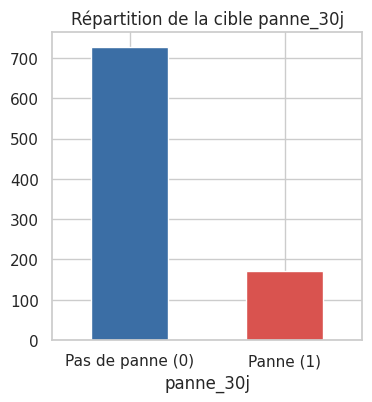

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))
df_clean[TARGET_COL].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#3b6ea5", "#d9534f"])
ax.set_xticklabels(["Pas de panne (0)", "Panne (1)"], rotation=0)
ax.set_title("Répartition de la cible panne_30j")
plt.show()
print(df_clean[TARGET_COL].value_counts(normalize=True))


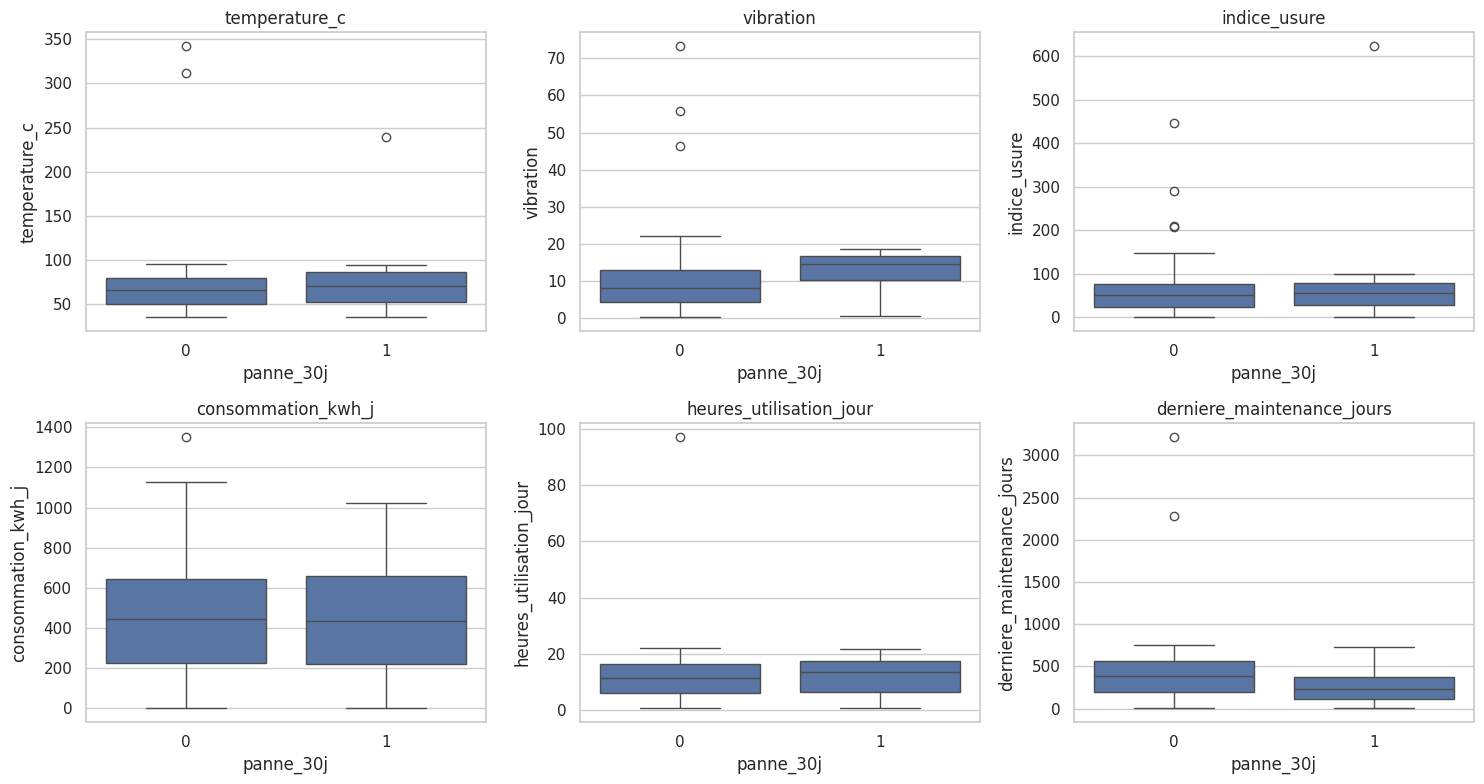

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols_to_plot = ["temperature_c", "vibration", "indice_usure", "consommation_kwh_j", "heures_utilisation_jour", "derniere_maintenance_jours"]
for ax, col in zip(axes.ravel(), cols_to_plot):
    sns.boxplot(data=df_clean, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


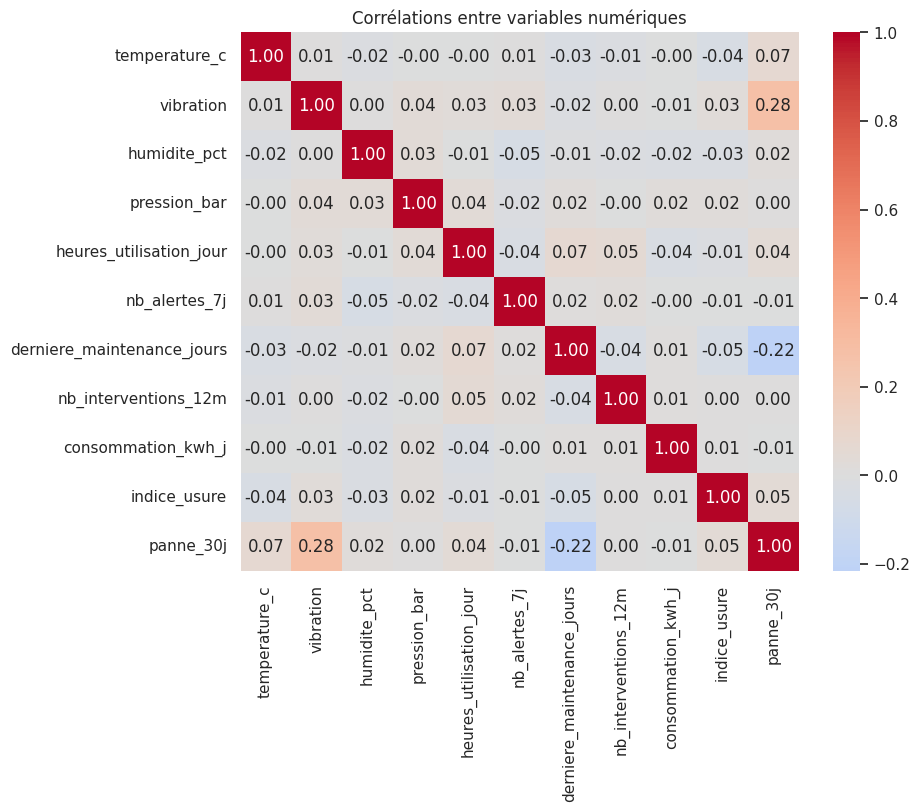

In [15]:
corr = df_clean[NUMERIC_COLS + [TARGET_COL]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Corrélations entre variables numériques")
plt.show()


## 5. Conclusion de l'exploration

Le nettoyage produit un jeu de données propre et exploitable
(`data/processed/panne_equipement_clean.csv`), avec :
- Toutes les colonnes numériques correctement typées.
- Aucune valeur manquante restante (imputation médiane/mode documentée).
- Les valeurs aberrantes conservées mais signalées via `outlier_flag`
  (décision documentée : elles peuvent être des signaux réels de
  dysfonctionnement, pas nécessairement des erreurs).

La suite (modélisation) se trouve dans `02_modelisation.ipynb`.
